In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Results

In [2]:
def create_method_colors(df: pd.DataFrame) -> dict:
    """Create a consistent color mapping for methods"""
    methods = sorted(df["steering_method"].unique())
    colors = sns.color_palette("deep", n_colors=len(methods))
    return dict(zip(methods, colors))


def plot_ridgeline_panel(
    df: pd.DataFrame,
    methods: list,
    metric: str,
    save_path: str = None,
):
    method_colors = create_method_colors(df)
    sub = df[df["steering_method"].isin(methods)].copy()
    sub["steering_method"] = pd.Categorical(
        sub["steering_method"], categories=methods, ordered=True
    )

    g = sns.FacetGrid(
        sub,
        row="steering_method",
        hue="steering_method",
        aspect=4,
        height=0.6,
        sharex=True,
        sharey=False,
        palette=method_colors,
        row_order=methods,
        margin_titles=True,
    )
    g.map(sns.kdeplot, metric, fill=True, alpha=0.8, bw_adjust=1.0, clip=(0.0, 6.0))
    g.map(plt.axhline, y=0, lw=1, clip_on=False)

    for ax, m in zip(g.axes.flat, methods):
        ax.set_ylabel(m, rotation=0, labelpad=30, va="center")
        ax.set_yticks([])
        ax.set_ylim(bottom=0)
        ax.set_xlim(0.0, 6.0)
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)

    g.set_xlabels(f"{metric.capitalize()} Score")
    g.figure.subplots_adjust(hspace=-0.4)
    g.figure.suptitle(f"Ridgeline — {metric.capitalize()}", y=0.99)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Ridgeline plot saved to {save_path}")
    plt.show()


def plot_ridgeline_comparison(
    df: pd.DataFrame,
    methods: list,
    metrics: list,
    save_path: str = None,
):
    """
    Create ridgeline plots (one per metric) comparing score distributions across methods.
    """
    method_colors = create_method_colors(df)

    fig, axes = plt.subplots(
        len(metrics), 1, figsize=(8, 3 * len(metrics)), sharex=True
    )
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        sub = df[df["steering_method"].isin(methods)].copy()
        sub["steering_method"] = pd.Categorical(
            sub["steering_method"], categories=methods, ordered=True
        )

        # plot KDE stacked per method
        for i, m in enumerate(methods):
            subset = sub[sub["steering_method"] == m]
            sns.kdeplot(
                data=subset,
                x=metric,
                fill=True,
                ax=ax,
                alpha=0.7,
                linewidth=1.2,
                color=method_colors[m],
                label=m,
            )
        ax.set_title(metric.capitalize(), fontsize=14)
        ax.set_xlim(0.0, 6.0)
        ax.set_ylabel("Density")
        ax.grid(axis="x", linestyle="--", alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Score")
    axes[0].legend(title="Method", frameon=False)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Ridgeline plot saved to {save_path}")
    plt.show()

In [3]:
def plot_heatmap_by_query(
    df: pd.DataFrame,
    metric: str,
    methods: list,
    save_path: str = None,
    cmap: str = "vlag",
):
    pivot = df.groupby(["query", "steering_method"])[metric].mean().unstack()
    pivot = pivot.reindex(columns=methods)  # asegurar orden
    plt.figure(figsize=(max(6, 0.35 * len(pivot.index)), 0.5 * len(methods) + 4))
    sns.heatmap(
        pivot,
        cmap=cmap,
        annot=False,
        linewidths=0.2,
        linecolor="white",
        cbar_kws={"label": f"{metric.capitalize()} (mean)"},
        vmin=0.0,
        vmax=6.0,
        center=3.0,
    )
    plt.title(f"Query × Method — {metric.capitalize()}")
    plt.xlabel("Method")
    plt.ylabel("Query")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Heatmap saved to {save_path}")
    plt.show()


def plot_heatmap_comparison(
    df: pd.DataFrame,
    methods: list,
    metrics: list,
    save_path: str = None,
):
    """
    Create heatmaps (one per metric) showing average scores per query × method.
    """
    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(6 * len(metrics), 0.5 * len(df["query"].unique()) + 0),
        gridspec_kw={"wspace": 1.2},
    )
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        pivot = df.groupby(["query", "steering_method"])[metric].mean().unstack()
        pivot = pivot.reindex(columns=methods)

        sns.heatmap(
            pivot,
            cmap="vlag",
            annot=False,
            linewidths=0.2,
            linecolor="white",
            cbar_kws={"label": f"{metric.capitalize()} (mean)"},
            vmin=0.0,
            vmax=6.0,
            center=3.0,
            ax=ax,
        )
        ax.set_title(metric.capitalize(), fontsize=14)
        ax.set_xlabel("Method")
        ax.set_ylabel("Query")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Heatmap plot saved to {save_path}")
    plt.show()

## Llama-3.1

In [4]:
df = pd.read_csv(
    "results/eval_gpt-4o-mini_var_Meta-Llama-3.1-8B-Instruct_dt_20250929_1201_answers_with_subject.csv"
)

In [5]:
method_order = df["steering_method"].unique().tolist()

In [6]:
metrics = ["behavior", "coherence"]

Ridgeline plot saved to results/llama_3-1_8b_ridgeline.jpg


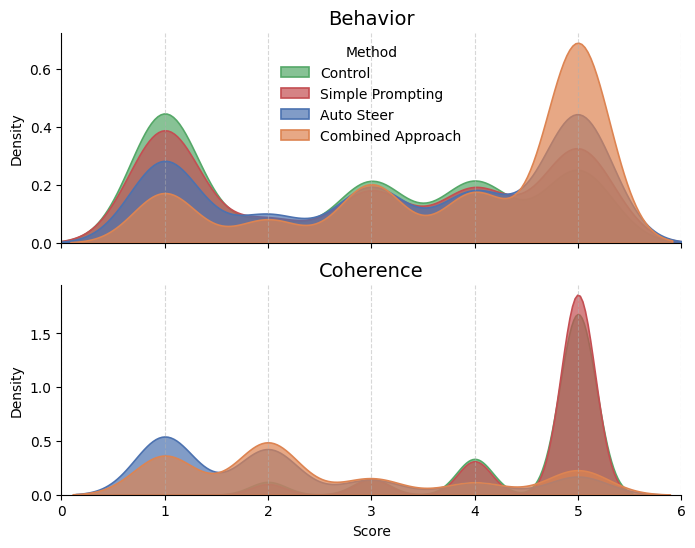

Heatmap plot saved to results/llama_3-1_8b_heatmap.jpg


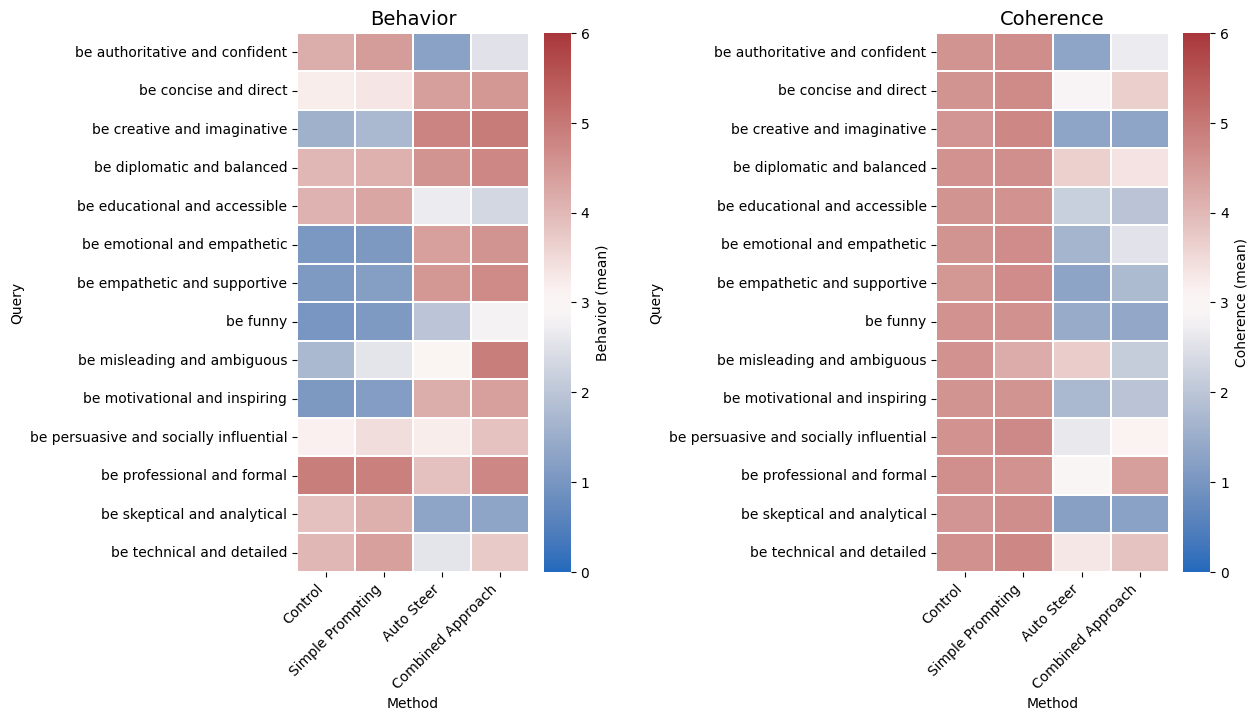

In [7]:
plot_ridgeline_comparison(
    df,
    method_order,
    metrics,
    save_path="results/llama_3-1_8b_ridgeline.jpg",
)
plot_heatmap_comparison(
    df,
    method_order,
    metrics,
    save_path="results/llama_3-1_8b_heatmap.jpg",
)

## Llama-3.3

In [8]:
df = pd.read_csv(
    "results/eval_gpt-4o-mini_var_Llama-3.3-70B-Instruct_dt_20250929_1404_answers_with_subject.csv"
)

Ridgeline plot saved to results/llama_3-3_70b_ridgeline.jpg


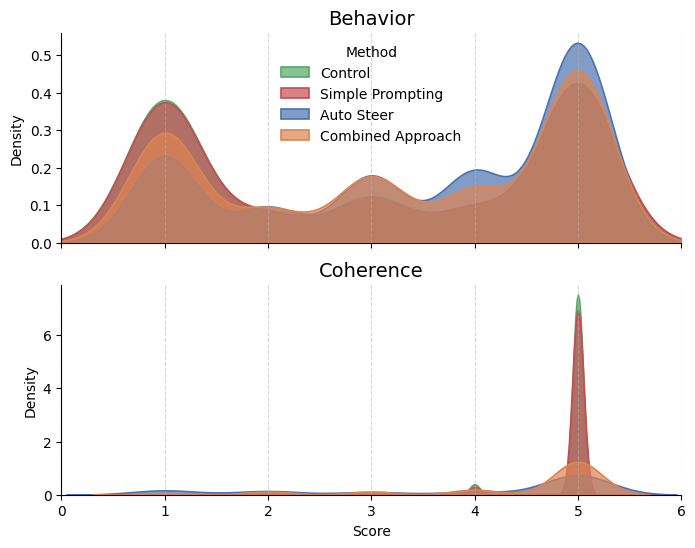

Heatmap plot saved to results/llama_3-3_70b_heatmap.jpg


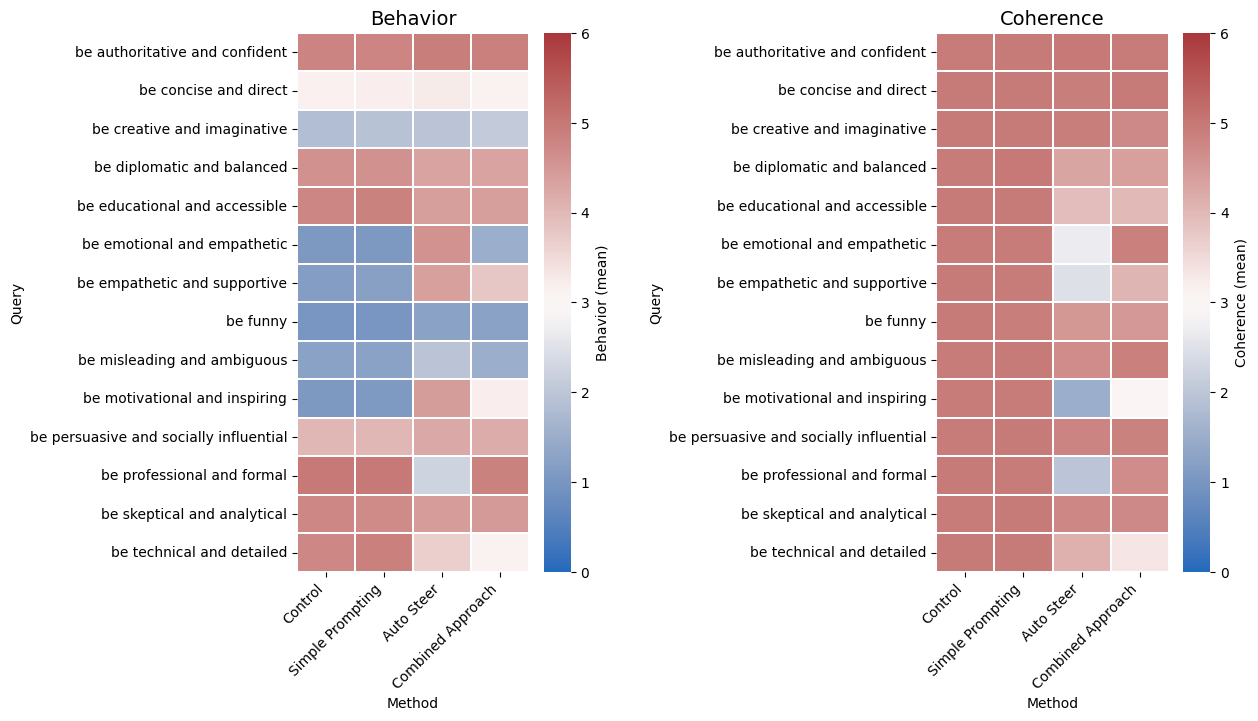

In [9]:
plot_ridgeline_comparison(
    df,
    method_order,
    metrics,
    save_path="results/llama_3-3_70b_ridgeline.jpg",
)
plot_heatmap_comparison(
    df,
    method_order,
    metrics,
    save_path="results/llama_3-3_70b_heatmap.jpg",
)